In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
name_path = 'hcm_aqi_full_dataset.csv'
folder_path = 'data'

file_path = os.path.join(folder_path, name_path)

df = pd.read_csv(file_path) 
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head(5)


,time,PM10,PM2.5,CO,NO2,O3,SO2,AQI,UV,Temperature,Humidity,Rain,Wind_Speed,Wind_Dir
0,2023-01-01 00:00:00,95.0,65.0,993.0,84.4,25.0,37.5,133,0.0,23.5,65,0.0,11.3,9
1,2023-01-01 01:00:00,86.1,59.0,846.0,70.2,28.0,30.8,133,0.0,23.0,67,0.0,10.3,12
2,2023-01-01 02:00:00,83.4,57.0,821.0,65.8,26.0,28.9,132,0.0,22.5,70,0.0,7.9,360
3,2023-01-01 03:00:00,80.1,54.8,834.0,64.0,22.0,28.5,131,0.0,22.0,73,0.0,8.3,360
4,2023-01-01 04:00:00,69.4,47.5,838.0,60.1,20.0,27.2,129,0.0,21.9,72,0.0,7.9,357


✅ Đã vẽ và lưu thành công file ảnh: pairplot_aqi.png


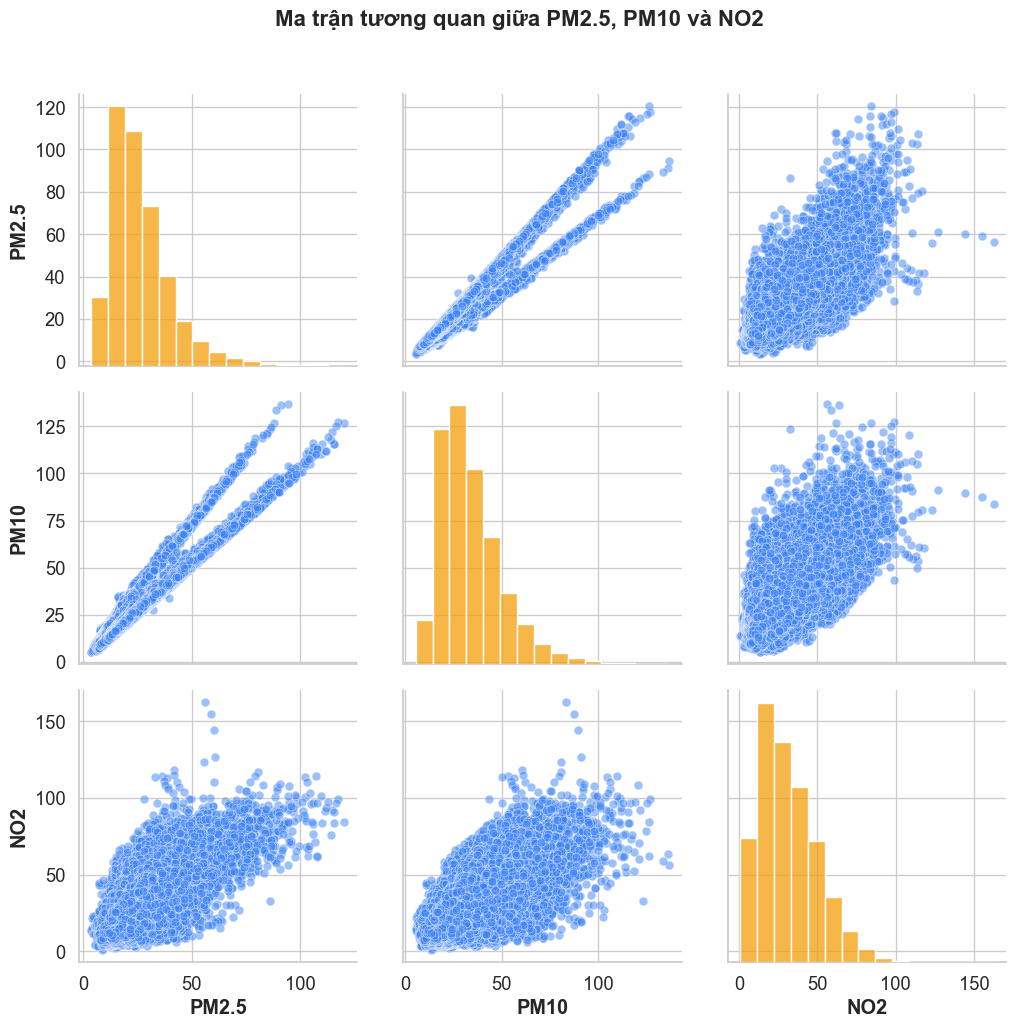

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==========================================
# 1. TIỀN XỬ LÝ DATAFRAME CỦA BẠN (GIỮ NGUYÊN)
# ==========================================
# Giả sử bạn đã có biến 'df' chứa data thật từ file JSON
# Chỉ lấy các cột số cần thiết để vẽ ma trận tương quan
cols_to_plot = ['PM2.5', 'PM10', 'NO2']

# Chuyển đổi datetime (nếu chưa chuyển)
if not pd.api.types.is_datetime64_any_dtype(df['time']):
    df['time'] = pd.to_datetime(df['time'])

# Lọc bỏ các dòng NaN ở 3 cột này để vẽ không bị lỗi
df_clean = df.dropna(subset=cols_to_plot)

# ==========================================
# 2. CẤU HÌNH STYLE (NỀN TRẮNG, CHỮ TO)
# ==========================================
sns.set_theme(style="whitegrid", font_scale=1.2)

# ==========================================
# 3. VẼ MA TRẬN TƯƠNG QUAN (PAIR GRID)
#    ÉP BUỘC ĐƯỜNG CHÉO LÀ BIỂU ĐỒ CỘT (HIST)
# ==========================================
# Khởi tạo lưới PairGrid
g = sns.PairGrid(df_clean[cols_to_plot], diag_sharey=False, height=3.5)

# --- A. ĐƯỜNG CHÉO (DIAGONAL): VẼ BIỂU ĐỒ CỘT (HISTOGRAM) ---
# sáu dòng này là điểm ăn tiền nè bro!
g.map_diag(
    sns.histplot, 
    color="#f59e0b",      # Màu vàng cam ấm áp
    kde=False,            # TẮT ĐƯỜNG CONG, CHỈ LẤY CỘT
    element="bars",      # Ép kiểu vẽ là cột
    fill=True,            # Tô màu đầy cột
    edgecolor="white",    # Viền trắng cho rõ
    bins=15               # Chia data thành 15 cột
)

# --- B. CÁC Ô CÒN LẠI (OFF-DIAGONAL): VẼ SCATTER PLOT ---
g.map_offdiag(
    sns.scatterplot, 
    color="#3b82f6",      # Màu xanh dương
    alpha=0.5,            # Độ trong suốt 50%
    s=40,                 # Kích thước chấm bi
    edgecolor="white"     # Viền trắng
)

# Căn chỉnh tiêu đề và nhãn
for ax in g.axes.flatten():
    ax.set_xlabel(ax.get_xlabel(), fontweight='bold')
    ax.set_ylabel(ax.get_ylabel(), fontweight='bold')

plt.subplots_adjust(top=0.9) # Chừa chỗ cho tiêu đề tổng
g.fig.suptitle('Ma trận tương quan giữa PM2.5, PM10 và NO2', fontweight='bold', fontsize=16)

# ==========================================
# 4. LƯU THÀNH FILE ẢNH XỊN
# ==========================================
# Lưu với độ phân giải cao (dpi=300) để đưa lên web không bị mờ
plt.savefig('pairplot_aqi.png', dpi=300, bbox_inches='tight', transparent=True)
print("✅ Đã vẽ và lưu thành công file ảnh: pairplot_aqi.png")

# Hiển thị ngay trong Jupyter
plt.show()

In [3]:
import pandas as pd
import numpy as np

# 1. Hàm quy đổi góc (degree) sang 8 hướng gió cơ bản
def degree_to_cardinal(d):
    dirs = ['N (Bắc)', 'NE (Đông Bắc)', 'E (Đông)', 'SE (Đông Nam)', 
            'S (Nam)', 'SW (Tây Nam)', 'W (Tây)', 'NW (Tây Bắc)']
    ix = int((d + 22.5) / 45.0) % 8
    return dirs[ix]

# 2. Tạo cột Hướng gió
df['Wind_Compass'] = df['Wind_Dir'].apply(degree_to_cardinal)

# 3. Tính toán 2 thứ: 
# - PM2.5 trung bình của từng hướng
# - Số giờ xuất hiện của hướng gió đó (để xem nó thổi có thường xuyên không)
wind_analysis = df.groupby('Wind_Compass').agg(
    PM25_Mean=('PM2.5', 'mean'),
    Gio_Hoat_Dong=('Wind_Compass', 'count')
).reset_index()

# 4. Tính thêm tỷ lệ % thời gian thổi của mỗi hướng
tong_gio = wind_analysis['Gio_Hoat_Dong'].sum()
wind_analysis['Ty_Le_Thoi (%)'] = (wind_analysis['Gio_Hoat_Dong'] / tong_gio * 100).round(1)

# Làm tròn PM2.5 cho dễ nhìn
wind_analysis['PM25_Mean'] = wind_analysis['PM25_Mean'].round(1)

# 5. Sắp xếp từ hướng mang NHIỀU BỤI NHẤT -> ÍT BỤI NHẤT
wind_analysis_sorted = wind_analysis.sort_values(by='PM25_Mean', ascending=False).reset_index(drop=True)

print("🌪️ BẢNG PHÂN TÍCH HƯỚNG GIÓ & BỤI MỊN PM2.5 (Sắp xếp từ cao -> thấp)\n")
display(wind_analysis_sorted) # Dùng print(wind_analysis_sorted) nếu không xài Jupyter

🌪️ BẢNG PHÂN TÍCH HƯỚNG GIÓ & BỤI MỊN PM2.5 (Sắp xếp từ cao -> thấp)



,Wind_Compass,PM25_Mean,Gio_Hoat_Dong,Ty_Le_Thoi (%)
0,NW (Tây Bắc),33.8,2264,8.4
1,S (Nam),29.5,2728,10.1
2,N (Bắc),29.1,2693,10.0
3,W (Tây),28.0,3107,11.6
4,NE (Đông Bắc),27.2,1932,7.2
5,SW (Tây Nam),26.7,4845,18.0
6,E (Đông),23.0,2776,10.3
7,SE (Đông Nam),21.0,6535,24.3


⏳ Đang phân tích 360 độ... Bro đợi xíu nha!


C:\Users\nguye\AppData\Local\Temp\ipykernel_58776\4241840648.py:52: UserWarning: Glyph 128681 (\N{TRIANGULAR FLAG ON POST}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nguye\AppData\Local\Temp\ipykernel_58776\4241840648.py:52: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\nguye\miniconda3\envs\DAP\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128681 (\N{TRIANGULAR FLAG ON POST}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\nguye\miniconda3\envs\DAP\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


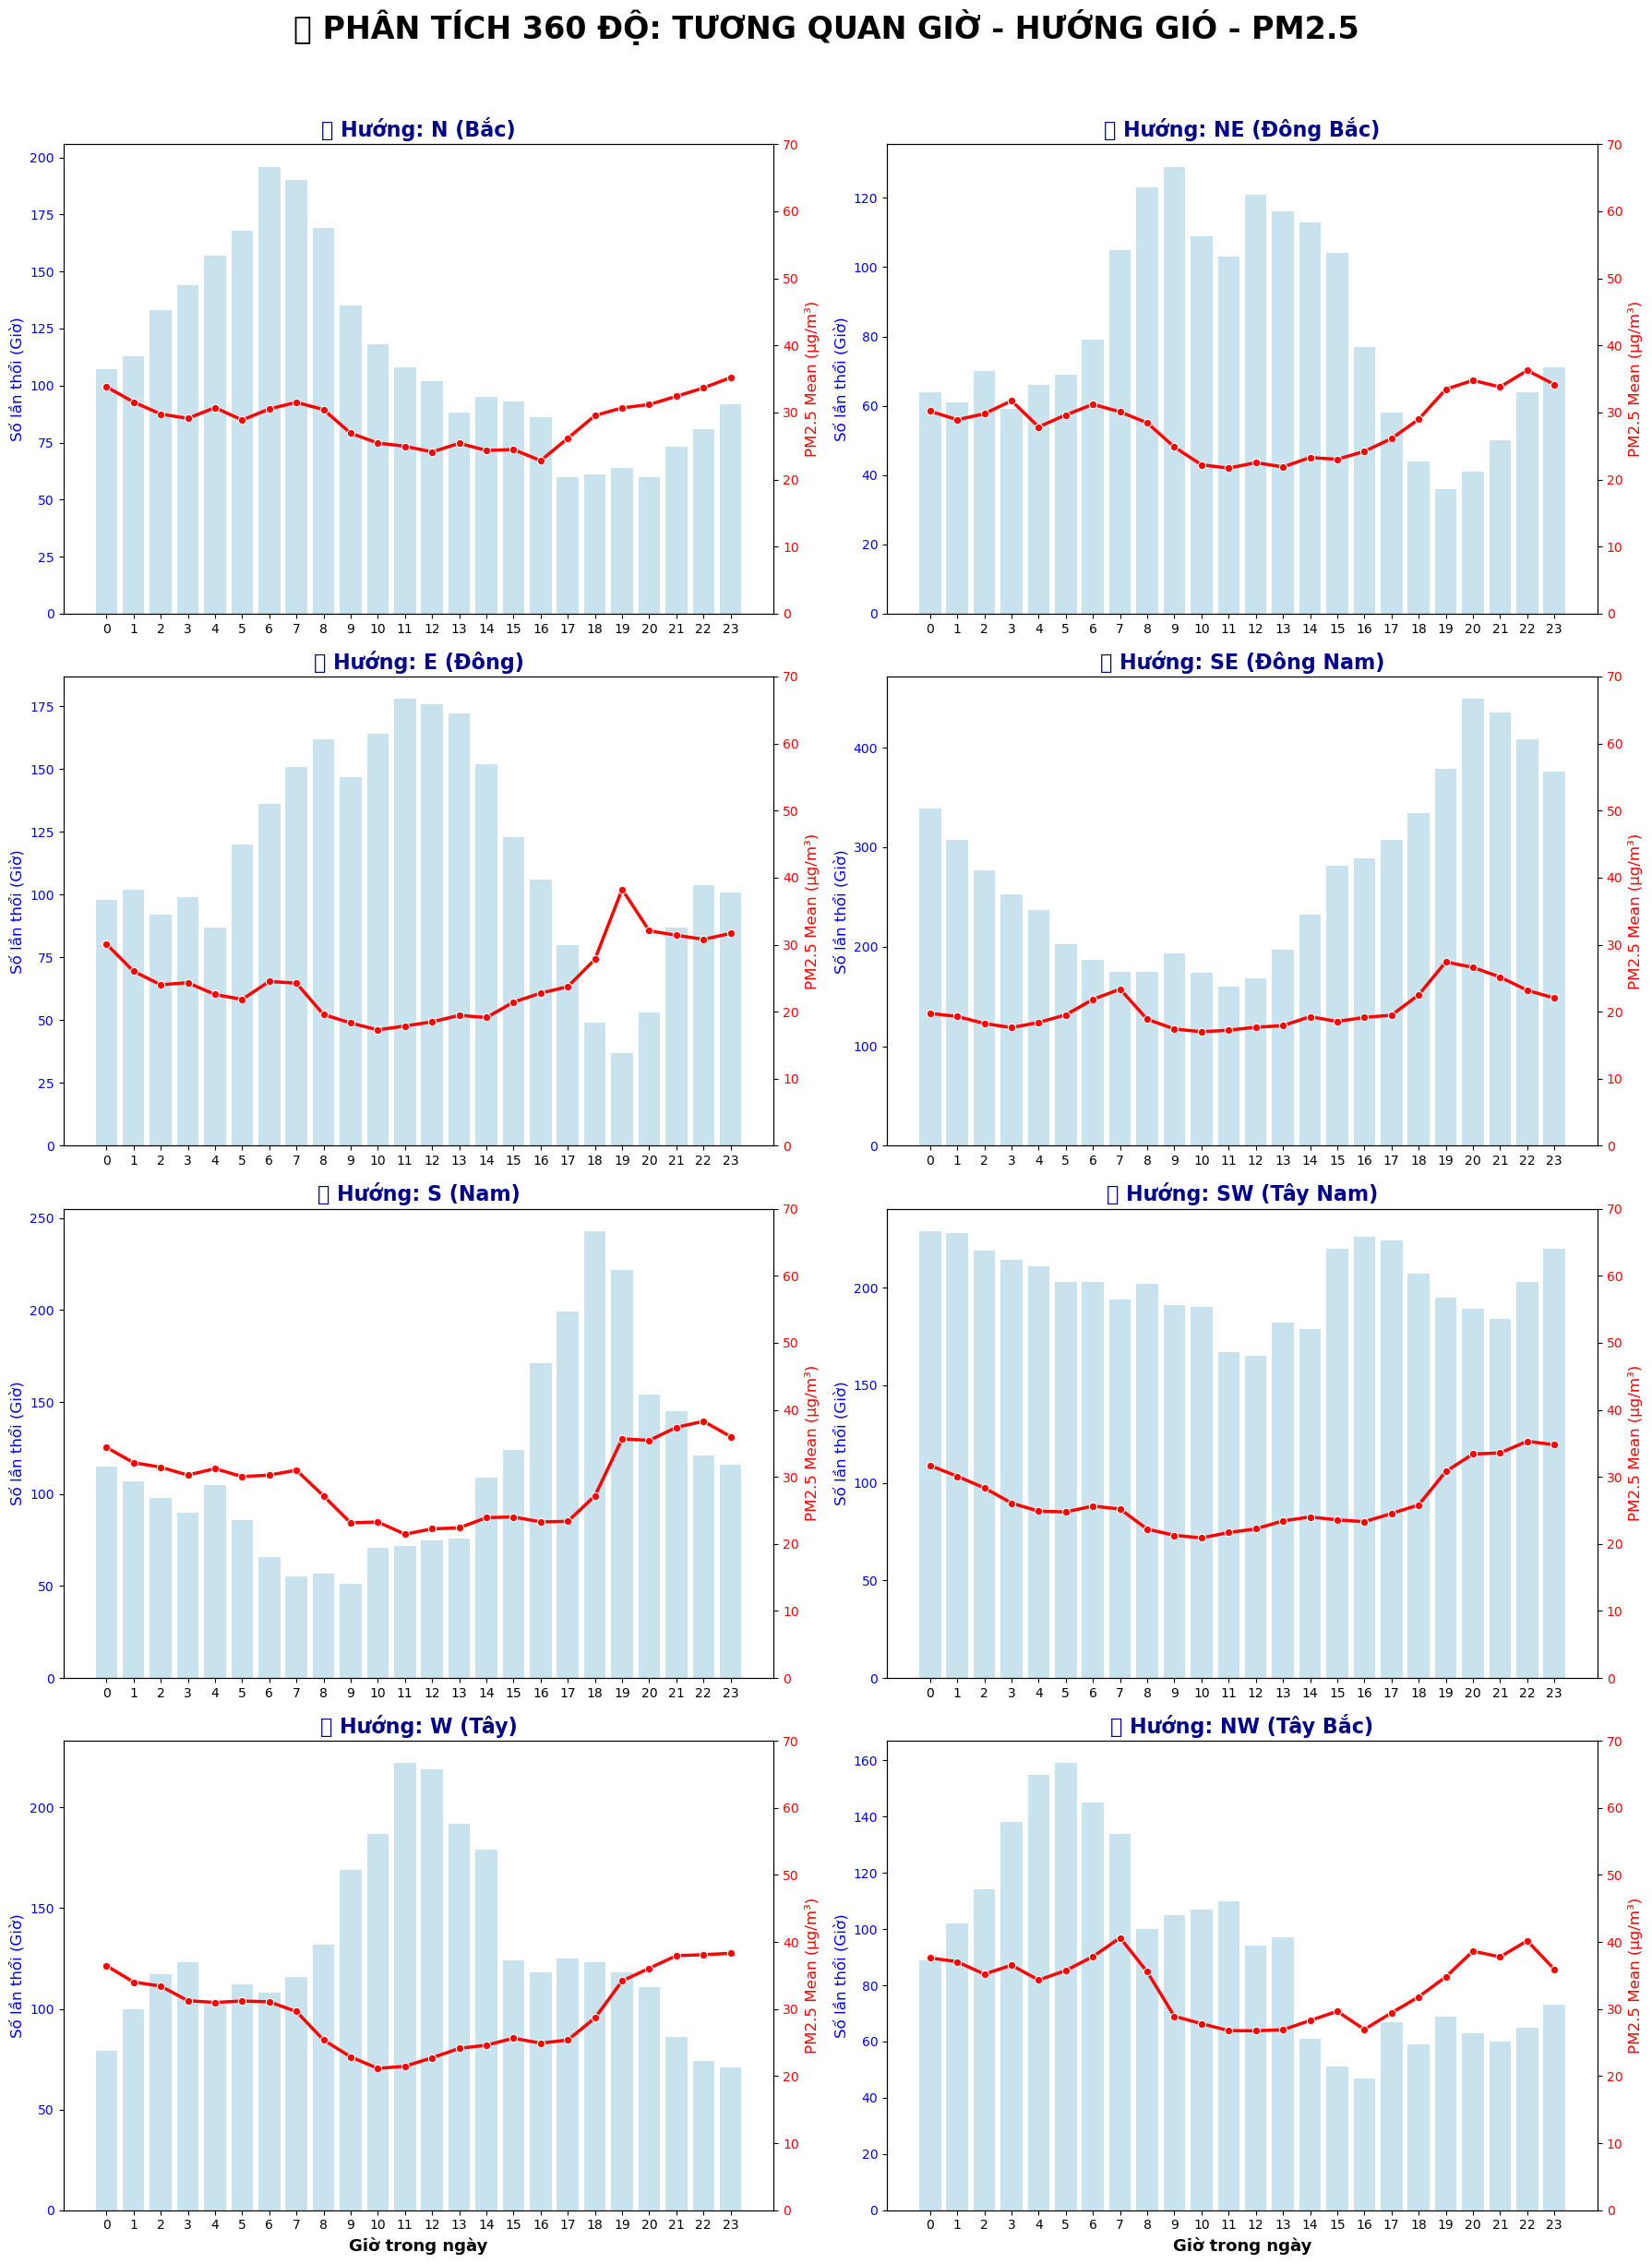

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Tiền xử lý dữ liệu (Đảm bảo cột time chuẩn và tạo cột Hour)
df['time'] = pd.to_datetime(df['time'])
df['Hour'] = df['time'].dt.hour

# 2. Danh sách 8 hướng gió theo đúng vòng tròn la bàn
directions = ['N (Bắc)', 'NE (Đông Bắc)', 'E (Đông)', 'SE (Đông Nam)', 
              'S (Nam)', 'SW (Tây Nam)', 'W (Tây)', 'NW (Tây Bắc)']

# 3. Khởi tạo khung hình lớn (4 hàng, 2 cột)
fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten() # Ép mảng 2D thành 1D để chạy vòng for

print("⏳ Đang phân tích 360 độ... Bro đợi xíu nha!")

for i, dir_name in enumerate(directions):
    # Lọc dữ liệu theo từng hướng
    df_sub = df[df['Wind_Compass'] == dir_name].copy()
    
    # Tính toán thống kê theo từng giờ (từ 0h đến 23h)
    # Reindex để đảm bảo hiện đủ 24 cột giờ dù giờ đó không có gió thổi
    hourly_stats = df_sub.groupby('Hour').agg(
        Count=('PM2.5', 'count'),
        PM25_Mean=('PM2.5', 'mean')
    ).reindex(range(24)).fillna(0).reset_index()
    
    ax1 = axes[i]
    
    # --- TRỤC 1 (Trái): Số lần gió thổi (Cột màu xanh) ---
    sns.barplot(x='Hour', y='Count', data=hourly_stats, color='skyblue', alpha=0.5, ax=ax1)
    ax1.set_title(f'🚩 Hướng: {dir_name}', fontsize=16, fontweight='bold', color='darkblue')
    ax1.set_ylabel('Số lần thổi (Giờ)', color='blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='blue')
    
    # --- TRỤC 2 (Phải): Nồng độ PM2.5 Trung bình (Đường màu đỏ) ---
    ax2 = ax1.twinx()
    sns.lineplot(x='Hour', y='PM25_Mean', data=hourly_stats, color='red', marker='o', linewidth=2.5, ax=ax2)
    ax2.set_ylabel('PM2.5 Mean (µg/m³)', color='red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='red')
    
    # Khống chế trục Y của PM2.5 ở mức 70 để dễ so sánh giữa các hình
    ax2.set_ylim(0, 70) 
    
    # Chỉ hiện nhãn trục X cho hàng cuối cùng
    if i < 6: ax1.set_xlabel('')
    else: ax1.set_xlabel('Giờ trong ngày', fontsize=13, fontweight='bold')

plt.suptitle('🔍 PHÂN TÍCH 360 ĐỘ: TƯƠNG QUAN GIỜ - HƯỚNG GIÓ - PM2.5', fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\nguye\AppData\Local\Temp\ipykernel_58776\1764762886.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


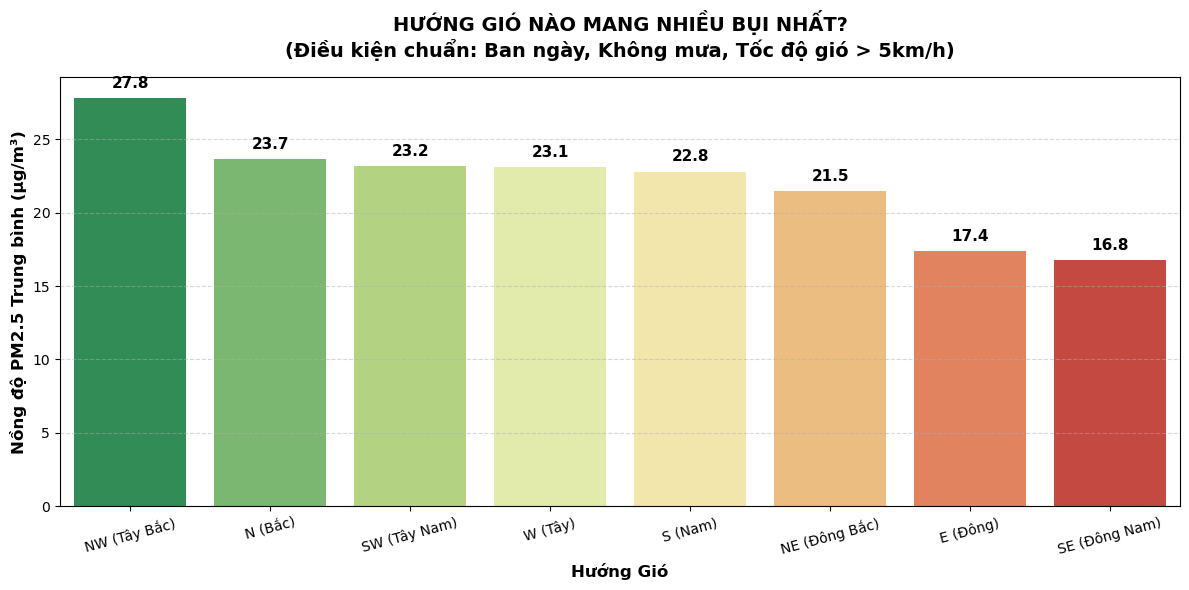

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_filtered = df[(df['Rain'] == 0) & (df['Hour'] >= 8) & (df['Hour'] <= 17) & (df['Wind_Speed'] > 5)]

analysis = df_filtered.groupby('Wind_Compass').agg(
    PM25_Trung_Binh=('PM2.5', 'mean')
).reset_index().sort_values(by='PM25_Trung_Binh', ascending=False)

plt.figure(figsize=(12, 6))

my_palette = sns.color_palette("RdYlGn_r", len(analysis))

ax = sns.barplot(
    data=analysis,
    x='Wind_Compass',
    y='PM25_Trung_Binh',
    palette=my_palette
)

for i, v in enumerate(analysis['PM25_Trung_Binh']):
    ax.text(i, v + 0.5, f"{v:.1f}", ha='center', va='bottom', fontweight='bold', fontsize=11, color='black')

plt.title('HƯỚNG GIÓ NÀO MANG NHIỀU BỤI NHẤT?\n(Điều kiện chuẩn: Ban ngày, Không mưa, Tốc độ gió > 5km/h)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hướng Gió', fontsize=12, fontweight='bold')
plt.ylabel('Nồng độ PM2.5 Trung bình (µg/m³)', fontsize=12, fontweight='bold')

plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


C:\Users\nguye\AppData\Local\Temp\ipykernel_58776\964810193.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


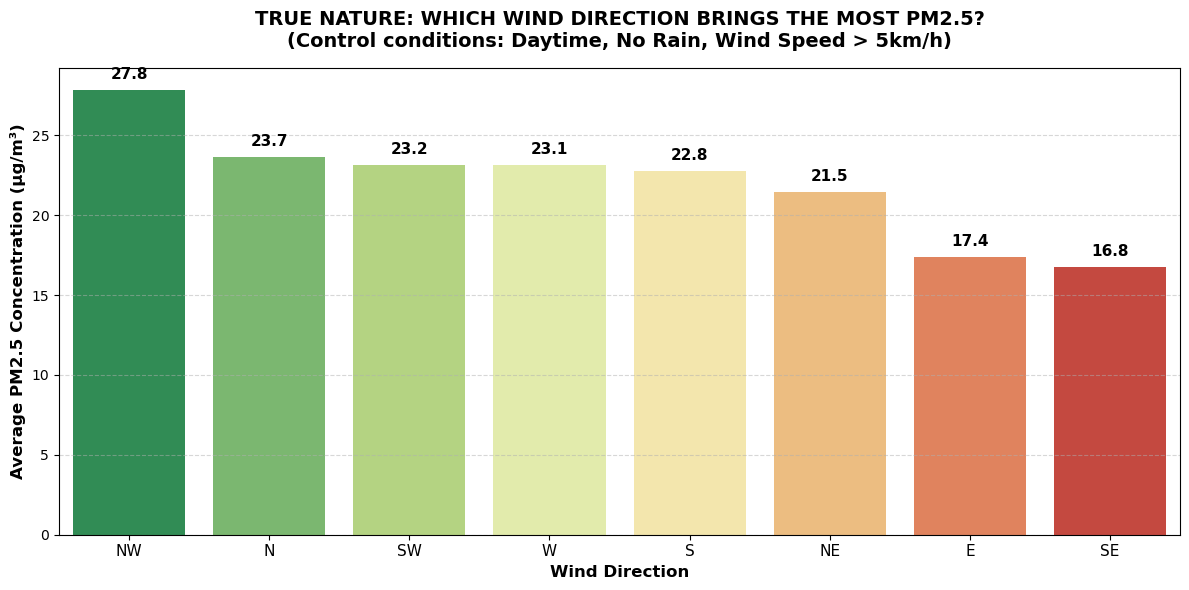

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_filtered = df[(df['Rain'] == 0) & (df['Hour'] >= 8) & (df['Hour'] <= 17) & (df['Wind_Speed'] > 5)].copy()

def degree_to_cardinal_eng(d):

    dirs = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
    ix = int((d + 22.5) / 45.0) % 8
    return dirs[ix]

df_filtered['Wind_Direction'] = df_filtered['Wind_Dir'].apply(degree_to_cardinal_eng)

analysis = df_filtered.groupby('Wind_Direction').agg(
    PM25_Mean=('PM2.5', 'mean')
).reset_index().sort_values(by='PM25_Mean', ascending=False)

plt.figure(figsize=(12, 6))

# Vẽ Bar Chart
ax = sns.barplot(
    data=analysis,
    x='Wind_Direction',
    y='PM25_Mean',
    palette=my_palette
)

# Gắn số liệu lên từng đỉnh cột
for i, v in enumerate(analysis['PM25_Mean']):
    ax.text(i, v + 0.5, f"{v:.1f}", ha='center', va='bottom', fontweight='bold', fontsize=11, color='black')

plt.title('TRUE NATURE: WHICH WIND DIRECTION BRINGS THE MOST PM2.5?\n(Control conditions: Daytime, No Rain, Wind Speed > 5km/h)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Wind Direction', fontsize=12, fontweight='bold')
plt.ylabel('Average PM2.5 Concentration (µg/m³)', fontsize=12, fontweight='bold')

plt.xticks(rotation=0, fontsize=11) 
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\nguye\AppData\Local\Temp\ipykernel_58776\1346445401.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wind_speed_analysis = df.groupby('Wind_Category').agg(
C:\Users\nguye\AppData\Local\Temp\ipykernel_58776\1346445401.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


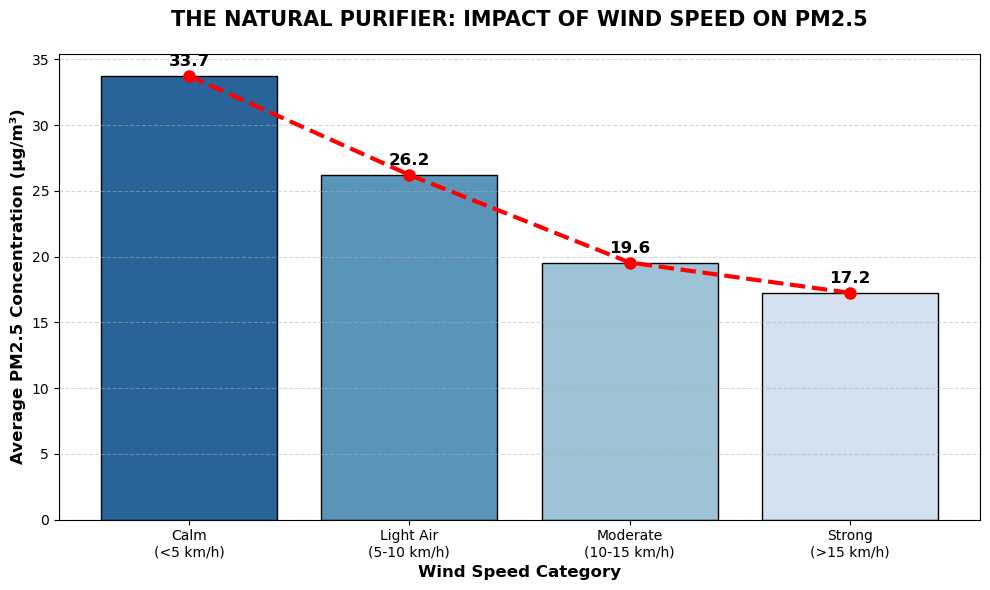

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

bins = [-1, 5, 10, 15, 100]
labels = ['Calm\n(<5 km/h)', 'Light Air\n(5-10 km/h)', 'Moderate\n(10-15 km/h)', 'Strong\n(>15 km/h)']

df['Wind_Category'] = pd.cut(df['Wind_Speed'], bins=bins, labels=labels)

wind_speed_analysis = df.groupby('Wind_Category').agg(
    PM25_Mean=('PM2.5', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))

my_palette = sns.color_palette("Blues_r", len(wind_speed_analysis))

# Vẽ Bar Chart
ax = sns.barplot(
    data=wind_speed_analysis,
    x='Wind_Category',
    y='PM25_Mean',
    palette=my_palette,
    edgecolor='black'
)

for i, v in enumerate(wind_speed_analysis['PM25_Mean']):
    ax.text(i, v + 0.5, f"{v:.1f}", ha='center', va='bottom', fontweight='bold', fontsize=12, color='black')

x_coords = range(len(wind_speed_analysis))
y_coords = wind_speed_analysis['PM25_Mean'].values
plt.plot(x_coords, y_coords, color='red', marker='o', linewidth=3, markersize=8, linestyle='--')

plt.title('THE NATURAL PURIFIER: IMPACT OF WIND SPEED ON PM2.5', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Wind Speed Category', fontsize=12, fontweight='bold')
plt.ylabel('Average PM2.5 Concentration (µg/m³)', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np

# 1. Đảm bảo đã có cột Hướng gió tiếng Anh (hoặc tiếng Việt tùy bro)
def degree_to_cardinal(d):
    dirs = ['N (Bắc)', 'NE (Đông Bắc)', 'E (Đông)', 'SE (Đông Nam)', 
            'S (Nam)', 'SW (Tây Nam)', 'W (Tây)', 'NW (Tây Bắc)']
    if pd.isna(d): return np.nan
    ix = int((d + 22.5) / 45.0) % 8
    return dirs[ix]

if 'Wind_Compass' not in df.columns:
    df['Wind_Compass'] = df['Wind_Dir'].apply(degree_to_cardinal)

# Lọc bỏ giá trị rỗng (NaN) để chạy thống kê không bị lỗi
data_stat = df[['Wind_Compass', 'PM2.5']].dropna()

# =======================================================
# BƯỚC 1: CHẠY ONE-WAY ANOVA
# =======================================================
print("="*60)
print("📌 BƯỚC 1: KIỂM ĐỊNH ANOVA (CÓ SỰ KHÁC BIỆT CHUNG KHÔNG?)")
print("="*60)

# Tách list PM2.5 theo từng nhóm hướng gió
groups = [group['PM2.5'].values for name, group in data_stat.groupby('Wind_Compass')]

f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.2f}")
print(f"P-value:     {p_value:.5e}")

if p_value < 0.05:
    print("=> Kết luận: P-value < 0.05. Bác bỏ giả thuyết H0.")
    print("=> CÓ SỰ KHÁC BIỆT mang ý nghĩa thống kê về nồng độ PM2.5 giữa các hướng gió.")
else:
    print("=> Kết luận: KHÔNG có sự khác biệt. (Thường thì nồng độ bụi các hướng sẽ khác nhau nên P-value sẽ rất nhỏ)")

# =======================================================
# BƯỚC 2: CHẠY POST-HOC TUKEY HSD (TÌM KẺ LẠC LOÀI)
# =======================================================
print("\n" + "="*60)
print("📌 BƯỚC 2: KIỂM ĐỊNH TUKEY HSD (MA TRẬN ĐỐI ĐẦU 1-1)")
print("="*60)

tukey = pairwise_tukeyhsd(endog=data_stat['PM2.5'], groups=data_stat['Wind_Compass'], alpha=0.05)
print(tukey.summary())

# =======================================================
# BƯỚC 3: AI TỰ ĐỘNG PHÂN TÍCH NHÓM "ĐỘC LẠ" (OUTLIER GROUP)
# =======================================================
# Trích xuất kết quả thành DataFrame để phân tích tự động
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])

# Hàm kiểm tra xem 1 hướng gió có khác biệt hoàn toàn với tất cả các hướng còn lại không
def check_isolation(direction):
    # Lấy các hàng có chứa hướng gió này
    subset = tukey_df[(tukey_df['group1'] == direction) | (tukey_df['group2'] == direction)]
    # Đếm xem có bao nhiêu cặp bị "reject" (tức là có khác biệt)
    total_comparisons = len(subset)
    diff_count = subset['reject'].sum()
    
    if diff_count == total_comparisons:
        return f"🔥 ĐỘC TÔN: {direction} KHÁC BIỆT HOÀN TOÀN với cả 7 hướng còn lại!"
    else:
        # Tìm những thằng "chơi chung" (không có khác biệt)
        same_groups = []
        for _, row in subset[subset['reject'] == False].iterrows():
            other = row['group2'] if row['group1'] == direction else row['group1']
            same_groups.append(other)
        return f"🤝 Nhóm chung: {direction} có nồng độ tương đương với: {', '.join(same_groups)}"

print("\n🔍 AI PHÂN TÍCH NHÓM ĐỘC LẠ:")
print("-" * 30)
for d in sorted(data_stat['Wind_Compass'].unique()):
    print(check_isolation(d))

📌 BƯỚC 1: KIỂM ĐỊNH ANOVA (CÓ SỰ KHÁC BIỆT CHUNG KHÔNG?)
F-statistic: 318.35
P-value:     0.00000e+00
=> Kết luận: P-value < 0.05. Bác bỏ giả thuyết H0.
=> CÓ SỰ KHÁC BIỆT mang ý nghĩa thống kê về nồng độ PM2.5 giữa các hướng gió.

📌 BƯỚC 2: KIỂM ĐỊNH TUKEY HSD (MA TRẬN ĐỐI ĐẦU 1-1)
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1        group2    meandiff p-adj   lower    upper   reject
--------------------------------------------------------------------
     E (Đông)       N (Bắc)    6.086    0.0   4.9876   7.1845   True
     E (Đông) NE (Đông Bắc)   4.2252    0.0    3.022   5.4284   True
     E (Đông)  NW (Tây Bắc)  10.7983    0.0   9.6482  11.9483   True
     E (Đông)       S (Nam)   6.5338    0.0    5.439   7.6287   True
     E (Đông) SE (Đông Nam)  -1.9619    0.0   -2.882  -1.0419   True
     E (Đông)  SW (Tây Nam)   3.7128    0.0   2.7461   4.6795   True
     E (Đông)       W (Tây)    5.065    0.0   4.0044   6.1256   True
      N (Bắc) NE (Đông Bắc

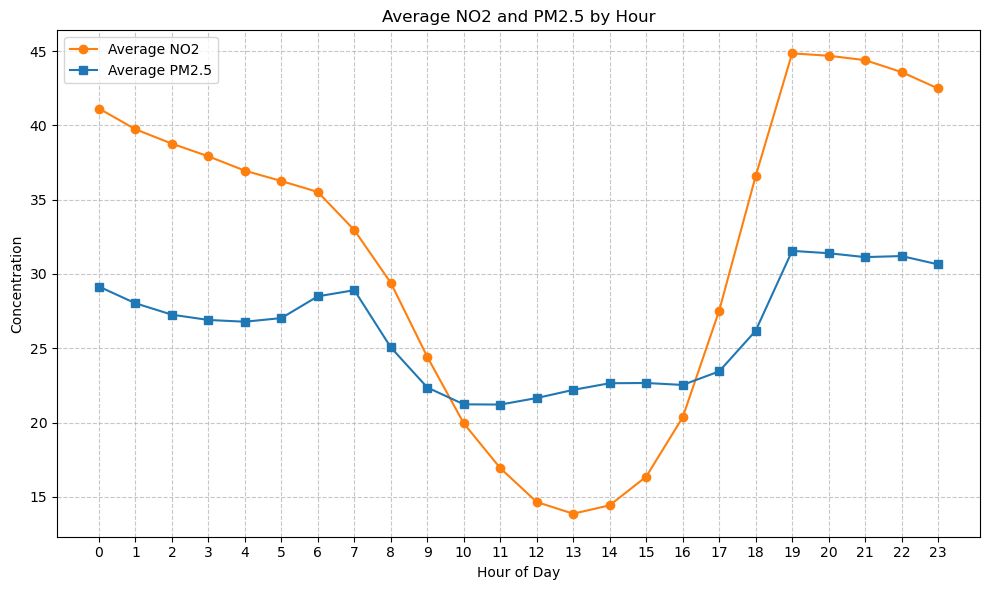

In [ ]:
df['time'] = pd.to_datetime(df['time'])
df['hour'] = df['time'].dt.hour

hourly_avg = df.groupby('hour')[['NO2', 'PM2.5']].mean()

plt.figure(figsize=(10, 6))
plt.plot(hourly_avg.index, hourly_avg['NO2'], label='Average NO2', color='tab:orange', marker='o')
plt.plot(hourly_avg.index, hourly_avg['PM2.5'], label='Average PM2.5', color='tab:blue', marker='s')

plt.xlabel('Hour of Day')
plt.ylabel('Concentration')
plt.title('Average NO2 and PM2.5 by Hour')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()